# Common Libraries

In [5]:
import os, sys, shutil
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"
import mujoco

# Params

In [6]:
# model_path = "/home/seojin/biomechanics_tools/myoconverter/models/mjc/Arm26/arm26_cvt3.xml"
model_path = "/mnt/ext1/seojin/temp/MOBL_ARMS_41/temp_cvt3.xml"
simulation_interval = 0.001

# Initialize model

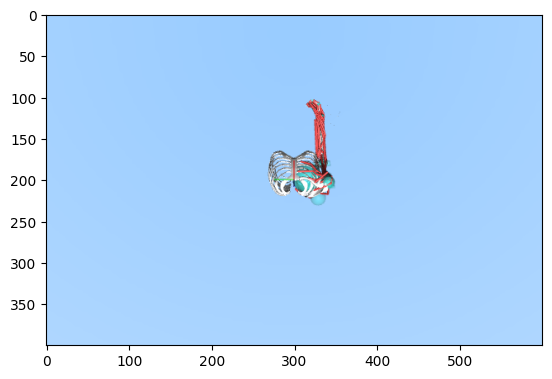

In [7]:
model = mujoco.MjModel.from_xml_path(model_path)
model.opt.timestep = simulation_interval
joint_names = [model.joint(i).name for i in range(model.njnt)]
muscle_names = [model.actuator(i).name for i in range(model.nu)]

mj_data = mujoco.MjData(model)
mujoco.mj_resetDataKeyframe(model, mj_data, 0)
mj_data.ctrl[:] = 0.0
mj_data.act[:] = 0.0

mujoco.mj_forward(model, mj_data)

# Renderer
renderer = mujoco.Renderer(model, height=400, width=600)
scene_option = mujoco.MjvOption()
scene_option.frame = mujoco.mjtFrame.mjFRAME_WORLD

# Camera
camera = mujoco.MjvCamera()
camera.azimuth = 0
camera.elevation = -110
camera.distance = 2.0

renderer.update_scene(mj_data, camera=camera, scene_option=scene_option)
plt.imshow(renderer.render())

t_x 0.0
t_y 0.0
t_z 0.0
r_x -4.533673657692359e-14
r_y -1.6007364457463586e-13
r_z 1.147504715443776e-13
sternoclavicular_r2 -3.258986970187152
sternoclavicular_r3 5.811020665262663
unrotscap_r3 -6.969095560364142
unrotscap_r2 2.5685455778372464
acromioclavicular_r2 3.4026343233303695
acromioclavicular_r3 -4.292991927059784
acromioclavicular_r1 5.015830769074937
unrothum_r1 22.30578282157196
unrothum_r3 -38.28119976890241
unrothum_r2 -126.55236873613072
elv_angle -127.13537519892529
shoulder_elv -11.911568268401432
shoulder1_r2 -127.1357650914252
shoulder_rot -127.13576509142511
elbow_flexion 13.114150556495408
pro_sup 0.44776391975678287
deviation -3.182080440936782
flexion 3.4573780106962775
wrist_hand_r1 4.931059195658095
wrist_hand_r3 3.432080607573881


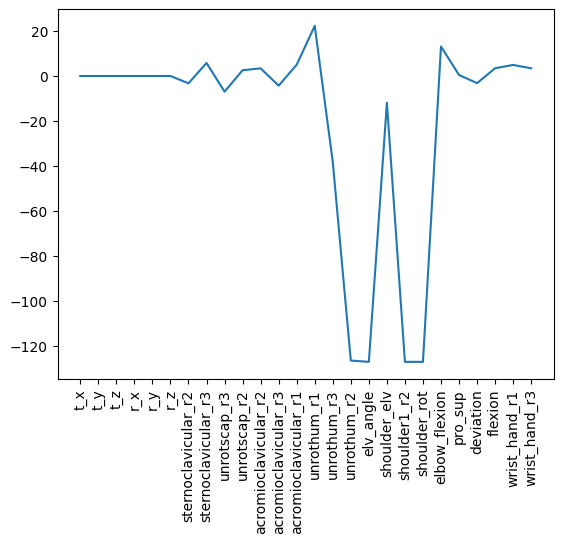

In [8]:
plt.plot(mj_data.qfrc_actuator)
plt.xticks(np.arange(len(joint_names)), joint_names, rotation = 90)
for j in range(model.njnt):
    name = model.joint(j).name
    adr = model.jnt_dofadr[j]
    dofnum = 1 if model.jnt_type[j] in [
        mujoco.mjtJoint.mjJNT_HINGE,
        mujoco.mjtJoint.mjJNT_SLIDE
    ] else 0
    if dofnum == 1:
        print(name, mj_data.qfrc_actuator[adr])

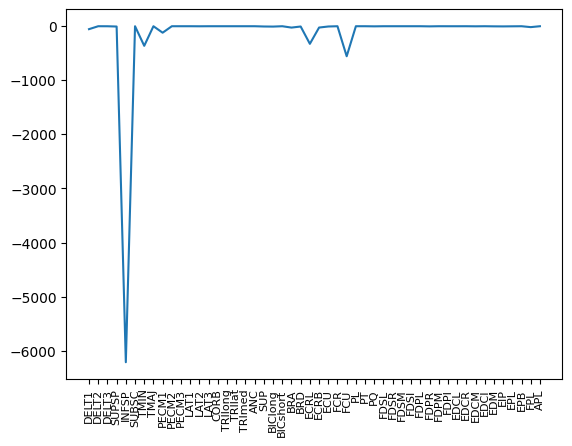

In [9]:
plt.plot(mj_data.actuator_force)
plt.xticks(np.arange(len(muscle_names)), muscle_names, rotation = 90, size = 8)
None

In [10]:
"""
# Passive force
for i in range(model.nu):
    if model.actuator_biastype[i] == mujoco.mjtBias.mjBIAS_MUSCLE:
        model.actuator_biastype[i] = mujoco.mjtBias.mjBIAS_NONE
"""

'\n# Passive force\nfor i in range(model.nu):\n    if model.actuator_biastype[i] == mujoco.mjtBias.mjBIAS_MUSCLE:\n        model.actuator_biastype[i] = mujoco.mjtBias.mjBIAS_NONE\n'

In [11]:
joint_name = "elv_angle"
jnt_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, joint_name)
dof_adr = model.jnt_dofadr[jnt_id]

sim_qpos = np.zeros_like(mj_data.qpos)
sim_qpos[dof_adr] = 0
mj_data.qpos[:] = sim_qpos

for i in range(model.nu):
    # Initialization
    mj_data.ctrl[:] = 0.0
    mj_data.act[:] = 0.0

    # Control
    mj_data.ctrl[i] = 1.0
    if model.actuator_dyntype[i] != mujoco.mjtDyn.mjDYN_NONE:
        act_adr = model.actuator_actadr[i]
        mj_data.act[act_adr] = 1.0

    # Simulation
    old_disableflags = model.opt.disableflags
    model.opt.disableflags |= mujoco.mjtDisableBit.mjDSBL_CONSTRAINT
    mujoco.mj_forward(model, mj_data)
    model.opt.disableflags = old_disableflags
    
    # History
    torque = mj_data.qfrc_actuator[dof_adr]

    # Analysis
    if abs(torque) > 1e-5:
        muscle_name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_ACTUATOR, i)
        if not muscle_name:
            muscle_name = f"Actuator {i}"
            
        direction = "양(+) 방향 (올림 주동근)" if torque > 0 else "음(-) 방향 (내림 길항근)"
        print(f"근육명: {muscle_name:25} | 작용 방향: {direction:15} | 토크: {torque:8.4f}")

근육명: DELT1                     | 작용 방향: 음(-) 방향 (내림 길항근) | 토크: -103.5198
근육명: DELT2                     | 작용 방향: 음(-) 방향 (내림 길항근) | 토크: -111.1630
근육명: DELT3                     | 작용 방향: 음(-) 방향 (내림 길항근) | 토크: -109.2162
근육명: SUPSP                     | 작용 방향: 음(-) 방향 (내림 길항근) | 토크: -110.2758
근육명: INFSP                     | 작용 방향: 음(-) 방향 (내림 길항근) | 토크: -107.7998
근육명: SUBSC                     | 작용 방향: 음(-) 방향 (내림 길항근) | 토크: -93.0810
근육명: TMIN                      | 작용 방향: 음(-) 방향 (내림 길항근) | 토크: -113.2050
근육명: TMAJ                      | 작용 방향: 음(-) 방향 (내림 길항근) | 토크: -105.5852
근육명: PECM1                     | 작용 방향: 음(-) 방향 (내림 길항근) | 토크: -98.6641
근육명: PECM2                     | 작용 방향: 음(-) 방향 (내림 길항근) | 토크: -92.1435
근육명: PECM3                     | 작용 방향: 음(-) 방향 (내림 길항근) | 토크: -106.6687
근육명: LAT1                      | 작용 방향: 음(-) 방향 (내림 길항근) | 토크: -103.5089
근육명: LAT2                      | 작용 방향: 음(-) 방향 (내림 길항근) | 토크: -103.1176
근육명: LAT3                      | 작용 방향: 음(-) 방향 (내림 길항

In [12]:
muscle_names = [mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_ACTUATOR, i) for i in range(model.nu)]

In [13]:
def get_muscle_lengths(model, mj_data):
    mujoco.mj_fwdPosition(model, mj_data)
    current_lengths = mj_data.actuator_length[:model.nu].copy()
    return current_lengths

In [17]:
mj_data.actuator_length

array([0.20676427, 0.20124118, 0.15580879, 0.11335542, 0.10484193,
       0.10789929, 0.12936496, 0.13459027, 0.12305893, 0.17493893,
       0.18199751, 0.25478258, 0.31059965, 0.33916795, 0.14740455,
       0.3028668 , 0.19096951, 0.17859731, 0.03372918, 0.06140686,
       0.40572282, 0.32519229, 0.13309821, 0.29767321, 0.32112371,
       0.28105182, 0.29634106, 0.30030998, 0.30283268, 0.3597573 ,
       0.14762148, 0.03117176, 0.4441554 , 0.4184762 , 0.38777389,
       0.39572002, 0.38372996, 0.41049508, 0.41262113, 0.38597504,
       0.43846209, 0.4496906 , 0.45256796, 0.44610515, 0.43390922,
       0.28990633, 0.29309643, 0.18291245, 0.30185336, 0.19789451])

In [14]:
get_muscle_lengths(model, mj_data)

array([0.20676427, 0.20124118, 0.15580879, 0.11335542, 0.10484193,
       0.10789929, 0.12936496, 0.13459027, 0.12305893, 0.17493893,
       0.18199751, 0.25478258, 0.31059965, 0.33916795, 0.14740455,
       0.3028668 , 0.19096951, 0.17859731, 0.03372918, 0.06140686,
       0.40572282, 0.32519229, 0.13309821, 0.29767321, 0.32112371,
       0.28105182, 0.29634106, 0.30030998, 0.30283268, 0.3597573 ,
       0.14762148, 0.03117176, 0.4441554 , 0.4184762 , 0.38777389,
       0.39572002, 0.38372996, 0.41049508, 0.41262113, 0.38597504,
       0.43846209, 0.4496906 , 0.45256796, 0.44610515, 0.43390922,
       0.28990633, 0.29309643, 0.18291245, 0.30185336, 0.19789451])

In [24]:
get_muscle_length_range(model)

,DELT1,DELT2,DELT3,SUPSP,INFSP,SUBSC,TMIN,TMAJ,PECM1,PECM2,...,EDCL,EDCR,EDCM,EDCI,EDM,EIP,EPL,EPB,FPL,APL
min,0.123363,0.135842,0.070162,0.069074,0.065656,0.092917,0.094551,0.098267,0.080951,0.153753,...,0.412481,0.409023,0.417782,0.412986,0.408090,0.281829,0.284059,0.174465,0.258420,0.182920
max,0.239460,0.210795,0.192737,0.138343,0.088646,0.127327,0.133885,0.202040,0.177853,0.267713,...,0.457286,0.475571,0.462137,0.475498,0.449768,0.293983,0.306454,0.194289,0.314983,0.215749


In [7]:
import pandas as pd

,DELT1,DELT2,DELT3,SUPSP,INFSP,SUBSC,TMIN,TMAJ,PECM1,PECM2,...,EDCL,EDCR,EDCM,EDCI,EDM,EIP,EPL,EPB,FPL,APL
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
for muscle_name in target_muscles:
    act_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, muscle_name)
    
    if act_id == -1:
        continue
        
    
    
    
    
    
    # 🛠️ [수정 2] lengthrange 데이터가 누락된 근육(0, 0) 예외 처리
    if min_length == 0 and max_length == 0:
        print(f"{muscle_name:<12} | {min_length:<10.4f} | {max_length:<10.4f} | {current_length:<10.4f} | ℹ️ 범위 미지정 (확인 불가)")
        continue
        
    # 상태 분석 논리 (서진님 코드 완벽함)
    status = "정상 (범위 내)"
    if current_length > max_length:
        status = "🚨 초과 (과도한 패시브 장력!)"
    elif current_length > max_length - (max_length - min_length) * 0.1:
        status = "⚠️ 한계 임박 (팽팽함)"
    elif current_length < min_length:
        status = "헐렁함 (Slack)"
        
    print(f"{muscle_name:<12} | {min_length:<10.4f} | {max_length:<10.4f} | {current_length:<10.4f} | {status}")

In [13]:
import mujoco

# 확인하고 싶은 근육 이름 (예: 엄청난 힘을 내던 DELT1이나 INFSP 등)
target_muscles = muscle_names

print(f"{'근육명':<10} | {'최소길이':<10} | {'최대길이':<10} | {'현재길이':<10} | 상태")
print("-" * 65)

# 현재 역학 상태 업데이트 (qpos=0 등 현재 자세 기준)
mujoco.mj_kinematics(model, mj_data)

for muscle_name in target_muscles:
    # 1. 근육(액추에이터) ID 찾기
    act_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, muscle_name)
    
    if act_id == -1:
        print(f"{muscle_name} 근육을 찾을 수 없습니다.")
        continue
        
    # 2. XML에 정의된 근육 길이 범위 (model.actuator_lengthrange)
    length_range = model.actuator_lengthrange[act_id]
    min_length = length_range[0]
    max_length = length_range[1]
    
    # 3. 현재 자세에서의 실제 근육 길이 (mj_data.actuator_length)
    current_length = mj_data.actuator_length[act_id]
    
    # 4. 상태 분석 (현재 길이가 최대 길이에 얼마나 가까운지/넘었는지)
    status = "정상 (범위 내)"
    if current_length > max_length:
        status = "🚨 초과 (과도한 패시브 장력!)"
    elif current_length > max_length - (max_length - min_length) * 0.1:
        status = "⚠️ 한계 임박 (팽팽함)"
    elif current_length < min_length:
        status = "헐렁함 (Slack)"
        
    print(f"{muscle_name:<10} | {min_length:<10.4f} | {max_length:<10.4f} | {current_length:<10.4f} | {status}")

근육명        | 최소길이       | 최대길이       | 현재길이       | 상태
-----------------------------------------------------------------
DELT1      | 0.1234     | 0.2395     | 0.2074     | 정상 (범위 내)
DELT2      | 0.1358     | 0.2108     | 0.2007     | 정상 (범위 내)
DELT3      | 0.0702     | 0.1927     | 0.1545     | 정상 (범위 내)
SUPSP      | 0.0691     | 0.1383     | 0.1127     | 정상 (범위 내)
INFSP      | 0.0657     | 0.0886     | 0.1016     | 🚨 초과 (과도한 패시브 장력!)
SUBSC      | 0.0929     | 0.1273     | 0.1097     | 정상 (범위 내)
TMIN       | 0.0946     | 0.1339     | 0.1262     | 정상 (범위 내)
TMAJ       | 0.0983     | 0.2020     | 0.1363     | 정상 (범위 내)
PECM1      | 0.0810     | 0.1779     | 0.1257     | 정상 (범위 내)
PECM2      | 0.1538     | 0.2677     | 0.1775     | 정상 (범위 내)
PECM3      | 0.1714     | 0.3174     | 0.1832     | 정상 (범위 내)
LAT1       | 0.2177     | 0.3323     | 0.2565     | 정상 (범위 내)
LAT2       | 0.2679     | 0.4159     | 0.3123     | 정상 (범위 내)
LAT3       | 0.3209     | 0.4640     | 0.3407     | 정상 (범위 내)
CO